# Business Insights & Recommendations

## 1. Revenue Performance
The startup generated ₹50.36 Crore in net revenue from 60,000 orders and approximately 9,976 customers. However, strong revenue generation did not translate into profitability.

## 2. Profitability Problem
The startup recorded an estimated business loss of ₹24.14 Crore with a profit margin of -47.93%. Operating expenses exceeded the gross profit generated from product sales.

## 3. High Operating Expenses
Technology and Operations were the highest-spending departments. Infrastructure was the largest expense category.

## 4. Refund Impact
The startup lost ₹4.91 Crore through refunds. Late Delivery was the largest return reason.

## 5. Recommended Actions
- Optimize Technology and Operations expenses.
- Reduce infrastructure and cloud costs.
- Improve delivery performance and logistics tracking.
- Strengthen product quality checks and packaging.
- Improve warehouse accuracy.
- Focus on profitable customer acquisition channels.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

products = pd.read_csv("../data/raw/products.csv")
orders = pd.read_csv("../data/raw/orders.csv")
returns = pd.read_csv("../data/raw/returns.csv")

print("Datasets loaded successfully!")

print("\nPRODUCTS COLUMNS:")
print(products.columns.tolist())

print("\nProducts Shape:", products.shape)

products.head()

Datasets loaded successfully!

PRODUCTS COLUMNS:
['product_id', 'product_name', 'category', 'sub_category', 'cost_price', 'selling_price']

Products Shape: (500, 6)


,product_id,product_name,category,sub_category,cost_price,selling_price
0,P1000,Wireless Headphones 1,Electronics,Standard,2397.93,4644.26
1,P1001,Hoodie 2,Fashion,Premium,1763.93,2295.47
2,P1002,Sneakers 3,Fashion,Basic,3701.00,6837.60
3,P1003,Mixer 4,Home & Kitchen,Standard,3585.73,7055.74
4,P1004,Dumbbell Set 5,Fitness,Premium,3129.83,5602.03


In [2]:
sales_product = orders.merge(
    products,
    on="product_id",
    how="left"
)

print("Sales + Product dataset created successfully!")
print("Shape:", sales_product.shape)

sales_product.head()

Sales + Product dataset created successfully!
Shape: (60000, 14)


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_percent,payment_method,order_status,product_name,category,sub_category,cost_price,selling_price
0,O100000,C101341,P1280,2025-06-28,2,6428.58,10,UPI,Delivered,Water Bottle 281,Home & Kitchen,Premium,3458.70,6428.58
1,O100001,C100981,P1252,2025-07-30,4,1455.88,0,UPI,Delivered,Sneakers 253,Fashion,Standard,814.29,1455.88
2,O100002,C109509,P1371,2025-06-29,4,3225.49,10,Credit Card,Delivered,Protein Shaker 372,Fitness,Basic,2147.13,3225.49
3,O100003,C101497,P1421,2025-03-30,2,3737.93,10,UPI,Delivered,Wireless Headphones 422,Electronics,Premium,1861.18,3737.93
4,O100004,C101120,P1302,2025-09-13,4,3921.72,20,Debit Card,Delivered,Wireless Headphones 303,Electronics,Premium,2460.58,3921.72


In [3]:
# Calculate financial metrics

# Gross revenue before discount
sales_product["gross_revenue"] = (
    sales_product["quantity"] *
    sales_product["unit_price"]
)

# Discount amount
sales_product["discount_amount"] = (
    sales_product["gross_revenue"] *
    sales_product["discount_percent"] / 100
)

# Net revenue after discount
sales_product["net_revenue"] = (
    sales_product["gross_revenue"] -
    sales_product["discount_amount"]
)

# Total product cost
sales_product["total_cost"] = (
    sales_product["quantity"] *
    sales_product["cost_price"]
)

# Gross profit
sales_product["gross_profit"] = (
    sales_product["net_revenue"] -
    sales_product["total_cost"]
)

# Profit margin percentage
sales_product["profit_margin"] = (
    sales_product["gross_profit"] /
    sales_product["net_revenue"]
) * 100

print("Product financial metrics calculated successfully!")

sales_product[
    [
        "product_id",
        "product_name",
        "quantity",
        "gross_revenue",
        "discount_amount",
        "net_revenue",
        "total_cost",
        "gross_profit",
        "profit_margin"
    ]
].head()

Product financial metrics calculated successfully!


,product_id,product_name,quantity,gross_revenue,discount_amount,net_revenue,total_cost,gross_profit,profit_margin
0,P1280,Water Bottle 281,2,12857.16,1285.716,11571.444,6917.40,4654.044,40.220080
1,P1252,Sneakers 253,4,5823.52,0.000,5823.520,3257.16,2566.360,44.068879
2,P1371,Protein Shaker 372,4,12901.96,1290.196,11611.764,8588.52,3023.244,26.036044
3,P1421,Wireless Headphones 422,2,7475.86,747.586,6728.274,3722.36,3005.914,44.675856
4,P1302,Wireless Headphones 303,4,15686.88,3137.376,12549.504,9842.32,2707.184,21.572040


In [4]:
product_performance = (
    sales_product.groupby(
        ["product_id", "product_name", "category"]
    )
    .agg(
        Total_Quantity=("quantity", "sum"),
        Total_Revenue=("net_revenue", "sum"),
        Total_Cost=("total_cost", "sum"),
        Total_Gross_Profit=("gross_profit", "sum"),
        Total_Discount=("discount_amount", "sum"),
        Total_Orders=("order_id", "count")
    )
    .reset_index()
)

# Calculate overall product profit margin
product_performance["Profit_Margin_%"] = (
    product_performance["Total_Gross_Profit"]
    / product_performance["Total_Revenue"]
) * 100

# Sort by revenue
product_performance = product_performance.sort_values(
    "Total_Revenue",
    ascending=False
)

print("PRODUCT PERFORMANCE SUMMARY")
print("=" * 70)

product_performance.head(10)

PRODUCT PERFORMANCE SUMMARY


,product_id,product_name,category,Total_Quantity,Total_Revenue,Total_Cost,Total_Gross_Profit,Total_Discount,Total_Orders,Profit_Margin_%
315,P1315,Sneakers 316,Fashion,364,2.671823e+06,1396729.88,1.275093e+06,183560.3640,144,47.723714
356,P1356,Sunscreen 357,Beauty,360,2.456967e+06,1258318.80,1.198648e+06,150278.7625,147,48.785691
491,P1491,Sneakers 492,Fashion,322,2.444263e+06,1237809.86,1.206453e+06,160146.9540,136,49.358567
92,P1092,Bluetooth Speaker 93,Electronics,316,2.439348e+06,1256912.12,1.182436e+06,149080.3860,125,48.473446
424,P1424,Storage Box 425,Home & Kitchen,341,2.350453e+06,1302255.13,1.048198e+06,157775.6895,136,44.595573
214,P1214,Table Lamp 215,Home & Kitchen,362,2.299453e+06,1383629.16,9.158238e+05,121023.8400,135,39.827899
455,P1455,Perfume 456,Beauty,280,2.248468e+06,1114268.40,1.134199e+06,129964.3200,112,50.443210
268,P1268,Face Wash 269,Beauty,338,2.243503e+06,1336046.40,9.074566e+05,134370.9830,130,40.448200
2,P1002,Sneakers 3,Fashion,347,2.227348e+06,1284247.00,9.431012e+05,145299.0000,145,42.341884
167,P1167,Yoga Mat 168,Fitness,329,2.219606e+06,1299145.33,9.204610e+05,143281.4985,120,41.469562


In [5]:
top_profit_products = product_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
).head(10)

print("TOP 10 PRODUCTS BY GROSS PROFIT")
print("=" * 60)

top_profit_products[
    [
        "product_name",
        "category",
        "Total_Revenue",
        "Total_Gross_Profit",
        "Profit_Margin_%"
    ]
]

TOP 10 PRODUCTS BY GROSS PROFIT


,product_name,category,Total_Revenue,Total_Gross_Profit,Profit_Margin_%
315,Sneakers 316,Fashion,2.671823e+06,1.275093e+06,47.723714
491,Sneakers 492,Fashion,2.444263e+06,1.206453e+06,49.358567
356,Sunscreen 357,Beauty,2.456967e+06,1.198648e+06,48.785691
92,Bluetooth Speaker 93,Electronics,2.439348e+06,1.182436e+06,48.473446
455,Perfume 456,Beauty,2.248468e+06,1.134199e+06,50.443210
149,Fitness Tracker 150,Fitness,2.079719e+06,1.077273e+06,51.798994
232,Hair Dryer 233,Beauty,2.192487e+06,1.073914e+06,48.981536
380,Wireless Headphones 381,Electronics,2.141014e+06,1.073328e+06,50.131749
370,T-Shirt 371,Fashion,2.097248e+06,1.056565e+06,50.378619
424,Storage Box 425,Home & Kitchen,2.350453e+06,1.048198e+06,44.595573


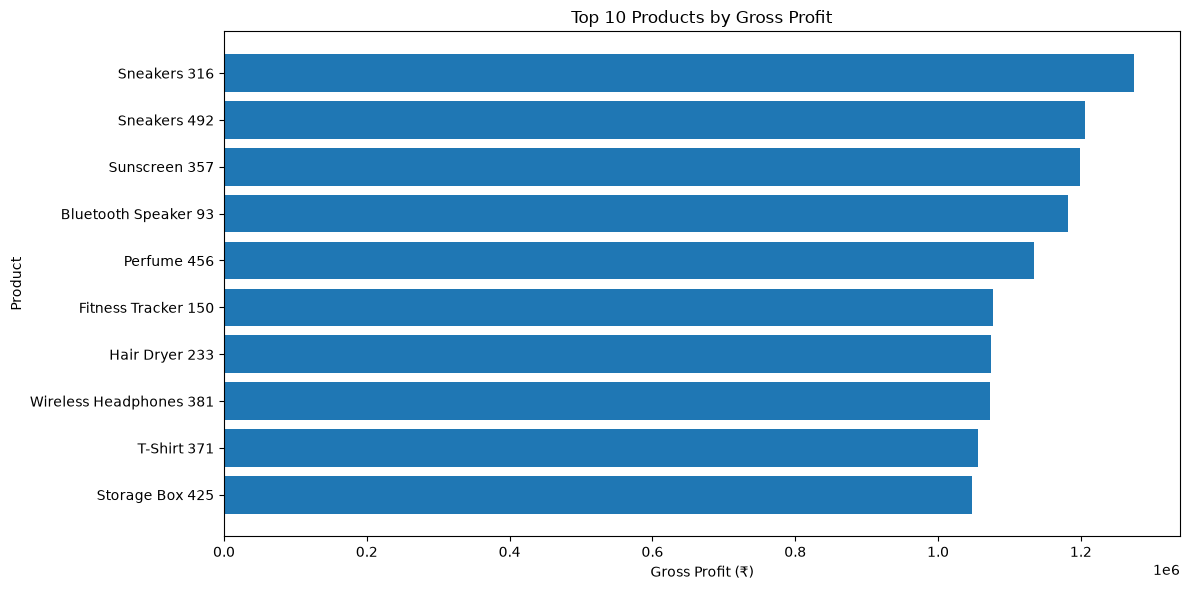

In [6]:
top_profit_products = top_profit_products.sort_values(
    "Total_Gross_Profit"
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_profit_products["product_name"],
    top_profit_products["Total_Gross_Profit"]
)

plt.xlabel("Gross Profit (₹)")
plt.ylabel("Product")
plt.title("Top 10 Products by Gross Profit")

plt.tight_layout()
plt.show()

In [7]:
category_performance = (
    product_summary
    .groupby("category")
    .agg(
        Total_Quantity=("Total_Quantity", "sum"),
        Total_Revenue=("Total_Revenue", "sum"),
        Total_Cost=("Total_Cost", "sum"),
        Total_Gross_Profit=("Total_Gross_Profit", "sum"),
        Total_Orders=("Total_Orders", "sum")
    )
)

category_performance["Profit_Margin_%"] = (
    category_performance["Total_Gross_Profit"]
    / category_performance["Total_Revenue"]
) * 100

category_performance = category_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

print("CATEGORY PERFORMANCE ANALYSIS")
print("=" * 70)

category_performance

NameError: name 'product_summary' is not defined